In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("warehouse_inventory_clustering_dataset.csv")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   item_id                          4000 non-null   object 
 1   category                         4000 non-null   object 
 2   subcategory                      4000 non-null   object 
 3   supplier_id                      4000 non-null   object 
 4   warehouse_zone                   4000 non-null   object 
 5   avg_monthly_demand               4000 non-null   int64  
 6   demand_variability               4000 non-null   float64
 7   avg_lead_time_days               4000 non-null   float64
 8   lead_time_variability            4000 non-null   float64
 9   monthly_reorder_count            4000 non-null   int64  
 10  stock_turnover_ratio             4000 non-null   float64
 11  days_in_inventory                4000 non-null   int64  
 12  stockout_frequency  

In [8]:
print(df.shape)

(4000, 25)


In [9]:
print(df.describe())

       avg_monthly_demand  demand_variability  avg_lead_time_days  \
count         4000.000000         4000.000000         4000.000000   
mean           331.809250            0.285640           10.301275   
std            228.438284            0.128173            5.592473   
min              1.000000            0.080000            1.000000   
25%            103.000000            0.190000            6.200000   
50%            333.000000            0.260000            9.000000   
75%            523.250000            0.370000           13.400000   
max            983.000000            0.620000           35.000000   

       lead_time_variability  monthly_reorder_count  stock_turnover_ratio  \
count            4000.000000            4000.000000           4000.000000   
mean                0.258738               4.707250              5.944282   
std                 0.165963               2.991118              3.804082   
min                 0.050000               0.000000              0.200

In [11]:
print(df.head())

    item_id        category       subcategory supplier_id warehouse_zone  \
0  ITM00001         Grocery            Snacks       S1036             B2   
1  ITM00002      Industrial  Electrical Parts       S1036             B1   
2  ITM00003         Apparel           Jackets       S1011             B2   
3  ITM00004      Automotive        Lubricants       S1030             A1   
4  ITM00005  Pharmaceutical   Medical Devices       S1064             A2   

   avg_monthly_demand  demand_variability  avg_lead_time_days  \
0                 310                0.26                 7.8   
1                 455                0.16                 4.8   
2                 350                0.43                20.9   
3                 121                0.33                 4.6   
4                  85                0.14                 7.3   

   lead_time_variability  monthly_reorder_count  ...  damage_rate  \
0                   0.05                      8  ...        0.012   
1             

In [18]:
#1
category_demand = df.groupby('category')['avg_monthly_demand'].mean()
print(category_demand)

category
Apparel           331.339216
Automotive        333.521822
Electronics       311.032129
Grocery           317.458696
Home & Kitchen    335.700405
Industrial        342.108108
Pharmaceutical    354.012024
Stationery        327.657895
Name: avg_monthly_demand, dtype: float64


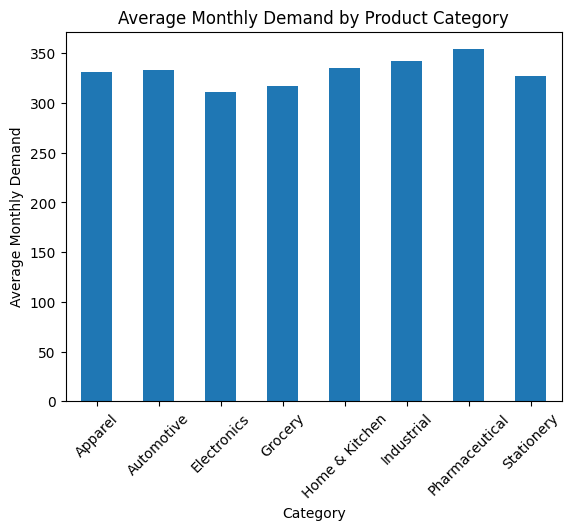

In [19]:
#1
category_demand.plot(kind='bar')
plt.title('Average Monthly Demand by Product Category')
plt.xlabel('Category')
plt.ylabel('Average Monthly Demand')
plt.xticks(rotation=45)
plt.show()

In [21]:
#2
demand_variability = df.groupby('category')['demand_variability'].mean()
print(demand_variability.sort_values(ascending=False))

category
Electronics       0.295663
Grocery           0.291500
Home & Kitchen    0.287652
Automotive        0.287173
Stationery        0.287045
Industrial        0.280637
Pharmaceutical    0.278337
Apparel           0.277902
Name: demand_variability, dtype: float64


In [22]:
#3
avg_demand = df.groupby('warehouse_zone')['avg_monthly_demand'].mean().sort_values(ascending=False)
print(avg_demand)

warehouse_zone
D1    344.346939
C2    340.298805
B2    338.925847
C1    330.073260
B1    328.317719
A1    325.836327
D2    324.181633
A2    323.202756
Name: avg_monthly_demand, dtype: float64


In [24]:
#4
longest_avg_supplier_leadstime = df.groupby('item_id')['avg_lead_time_days'].mean().sort_values(ascending=False).head(10)
print(longest_avg_supplier_leadstime)

item_id
ITM01917    35.0
ITM01309    35.0
ITM00040    35.0
ITM00380    33.9
ITM00926    33.6
ITM02559    32.0
ITM03567    31.9
ITM01665    30.8
ITM01789    30.6
ITM00332    30.6
Name: avg_lead_time_days, dtype: float64


In [68]:
#5
correlation_of_association = df['lead_time_variability'].corr(df['supplier_delay_incidents'])
print("Correlation_of_association:", correlation)

Correlation_of_association: 0.7209340333153956


In [26]:
#6
highest_stock_turnover = df.groupby('item_id')['stock_turnover_ratio'].mean().sort_values(ascending=False).head(10)
print(highest_stock_turnover)

item_id
ITM00427    15.89
ITM02465    15.69
ITM02780    15.34
ITM01419    15.18
ITM02843    15.01
ITM01129    15.00
ITM03703    15.00
ITM03622    15.00
ITM03405    15.00
ITM01766    14.94
Name: stock_turnover_ratio, dtype: float64


In [28]:
#7
inventory_days = df.groupby('item_id')['days_in_inventory'].mean().sort_values(ascending=False).head(10)
print(inventory_days)

item_id
ITM00644    273.0
ITM02773    272.0
ITM03079    268.0
ITM00681    261.0
ITM03723    258.0
ITM01180    252.0
ITM02296    249.0
ITM00548    247.0
ITM01374    246.0
ITM02694    246.0
Name: days_in_inventory, dtype: float64


In [65]:
#8
Correlation_of_str_and_dii = df['stock_turnover_ratio'].corr(df['days_in_inventory'])
print("Correlation_of_str_and_dii:", correlation)

Correlation_of_str_and_dii: 0.7209340333153956


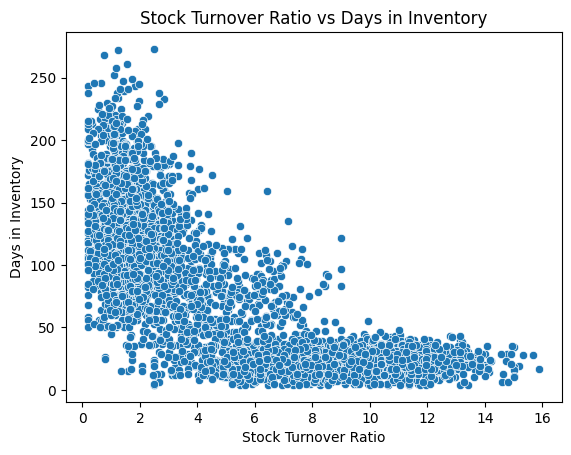

In [30]:
#8
sns.scatterplot(x=df['stock_turnover_ratio'],y=df['days_in_inventory'])
plt.title('Stock Turnover Ratio vs Days in Inventory')
plt.xlabel('Stock Turnover Ratio')
plt.ylabel('Days in Inventory')
plt.show()

In [32]:
#9
stockout_frequency = df.groupby('item_id')['stockout_frequency'].mean().sort_values(ascending=False).head(10)
print(stockout_frequency)

item_id
ITM02972    15.0
ITM03758    15.0
ITM03423    15.0
ITM03625    15.0
ITM02850    15.0
ITM01627    15.0
ITM02285    15.0
ITM02256    15.0
ITM02537    15.0
ITM01902    15.0
Name: stockout_frequency, dtype: float64


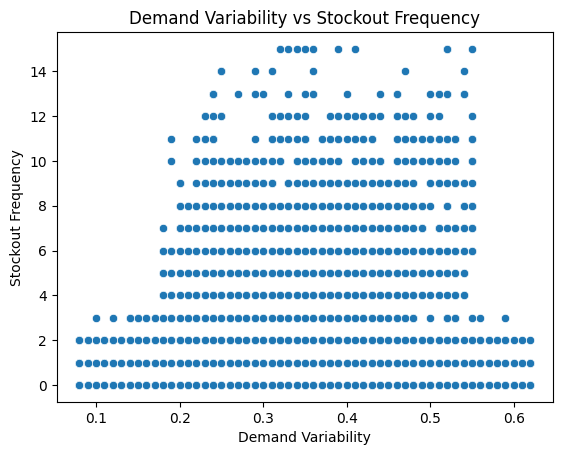

In [33]:
#10
sns.scatterplot(x=df['demand_variability'],y=df['stockout_frequency'])
plt.title('Demand Variability vs Stockout Frequency')
plt.xlabel('Demand Variability')
plt.ylabel('Stockout Frequency')
plt.show()

In [34]:
#11
backorder_frequency = df.groupby('item_id')['backorder_frequency'].mean().sort_values(ascending=False).head(10)
print(backorder_frequency)

item_id
ITM01459    14.0
ITM01872    13.0
ITM03742    13.0
ITM03982    13.0
ITM02144    13.0
ITM03813    13.0
ITM02375    13.0
ITM01994    12.0
ITM03098    12.0
ITM03093    12.0
Name: backorder_frequency, dtype: float64


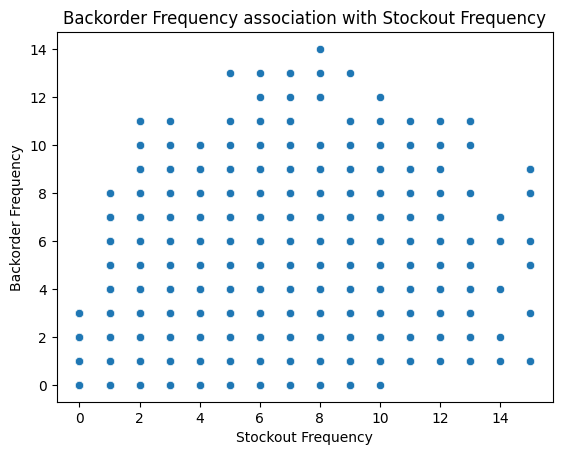

In [38]:
#12
sns.scatterplot(x=df['stockout_frequency'],y=df['backorder_frequency'])
plt.title('Backorder Frequency association with Stockout Frequency')
plt.xlabel('Stockout Frequency')
plt.ylabel('Backorder Frequency')
plt.show()

In [39]:
#13
reorderpoint_breaches = df.groupby('item_id')['reorder_point_breaches'].mean().sort_values(ascending=False).head(10)
print(reorderpoint_breaches)

item_id
ITM00242    17.0
ITM00649    17.0
ITM02342    16.0
ITM01548    16.0
ITM03237    16.0
ITM03247    15.0
ITM01144    15.0
ITM02825    15.0
ITM02270    15.0
ITM02158    15.0
Name: reorder_point_breaches, dtype: float64


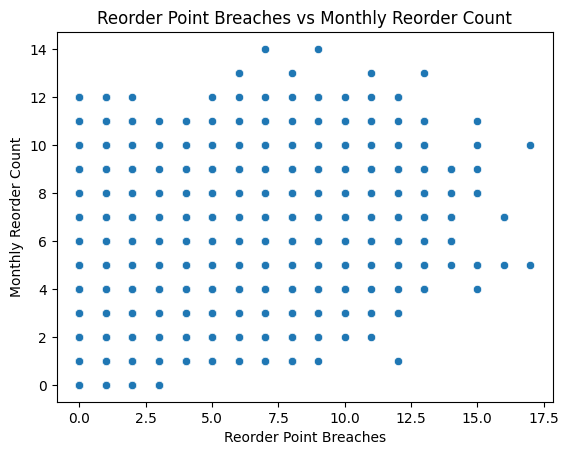

In [42]:
#14
sns.scatterplot(x=df['reorder_point_breaches'],y=df['monthly_reorder_count'])
plt.title('Reorder Point Breaches vs Monthly Reorder Count')
plt.xlabel('Reorder Point Breaches')
plt.ylabel('Monthly Reorder Count')
plt.show()

In [43]:
#15
supplier_delay_incidents= df.groupby('item_id')['supplier_delay_incidents'].mean().sort_values(ascending=False).head(10)
print(supplier_delay_incidents)

item_id
ITM01306    18.0
ITM01806    18.0
ITM02230    17.0
ITM00192    17.0
ITM02516    16.0
ITM00366    16.0
ITM02623    16.0
ITM01128    16.0
ITM01476    16.0
ITM03162    15.0
Name: supplier_delay_incidents, dtype: float64


In [44]:
#16
delay_stockout = df['supplier_delay_incidents'].corr(df['stockout_frequency'])
print("supplier_delay_incidnets vs stockout_frequency:", delay_stockout)

supplier_delay_incidnets vs stockout_frequency: 0.6103354000135495


In [69]:
#17

In [45]:
#18
excess_stock_levels = df.groupby('item_id')['excess_stock_level'].mean().sort_values(ascending=False).head(10)
print(excess_stock_levels)

item_id
ITM01019    622.0
ITM02018    591.0
ITM01376    568.0
ITM02015    542.0
ITM02510    539.0
ITM03530    536.0
ITM02315    503.0
ITM03406    495.0
ITM01172    487.0
ITM03062    484.0
Name: excess_stock_level, dtype: float64


In [47]:
#19
correlation = df['excess_stock_level'].corr(df['days_in_inventory'])
print("Correlation:", correlation)

Correlation: 0.7290019123386767


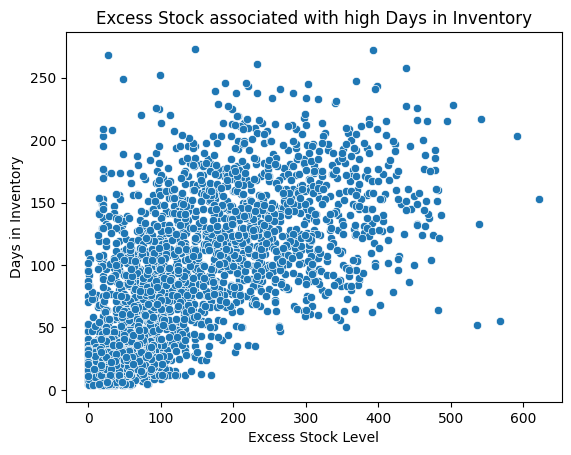

In [49]:
#19
sns.scatterplot(x=df['excess_stock_level'],y=df['days_in_inventory'])
plt.title('Excess Stock associated with high Days in Inventory')
plt.xlabel('Excess Stock Level')
plt.ylabel('Days in Inventory')
plt.show()

In [50]:
#20
highest_inventory_value = df.groupby('item_id')['inventory_value'].mean().sort_values(ascending=False).head(10)
print(highest_inventory_value)

item_id
ITM01254    2093353.52
ITM00156    1993974.96
ITM00707    1905333.80
ITM03470    1902986.23
ITM03719    1775518.85
ITM01078    1699984.38
ITM03086    1687486.24
ITM01183    1632093.78
ITM01599    1590946.24
ITM03736    1563724.36
Name: inventory_value, dtype: float64


In [51]:
#21
highest_holding_cost_perunit = df.groupby('item_id')['holding_cost_per_unit'].mean().sort_values(ascending=False).head(10)
print(highest_holding_cost_perunit)

item_id
ITM01254    502.57
ITM02258    477.00
ITM03548    470.56
ITM03736    468.89
ITM01978    427.05
ITM00707    391.89
ITM03591    390.88
ITM02766    380.79
ITM02710    377.69
ITM03664    353.22
Name: holding_cost_per_unit, dtype: float64


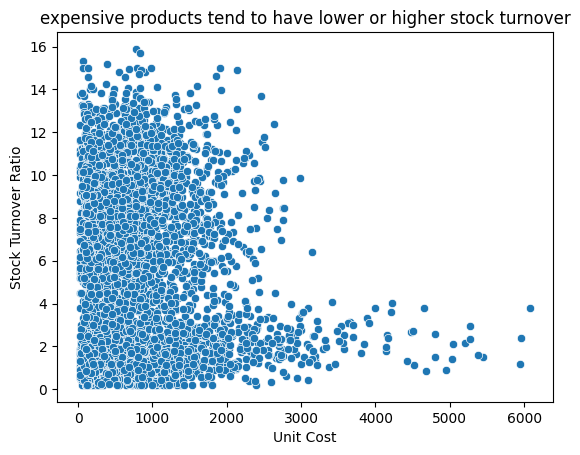

In [63]:
#22
sns.scatterplot(x=df['unit_cost'],y=df['stock_turnover_ratio'])
plt.title('expensive products tend to have lower or higher stock turnover')
plt.xlabel('Unit Cost')
plt.ylabel('Stock Turnover Ratio')
plt.show()

In [53]:
#23
highest_return_rates = df.groupby('item_id')['return_rate'].mean().sort_values(ascending=False).head(10)
print(highest_return_rates)

item_id
ITM02360    0.080
ITM02962    0.080
ITM02624    0.080
ITM02585    0.080
ITM03521    0.079
ITM00824    0.079
ITM02124    0.079
ITM00372    0.079
ITM00890    0.079
ITM00463    0.079
Name: return_rate, dtype: float64


In [54]:
#24
highest_damage_rates = df.groupby('item_id')['damage_rate'].mean().sort_values(ascending=False).head(10)
print(highest_damage_rates)

item_id
ITM01406    0.04
ITM00703    0.04
ITM02628    0.04
ITM01590    0.04
ITM01161    0.04
ITM02278    0.04
ITM02814    0.04
ITM01472    0.04
ITM02056    0.04
ITM03289    0.04
Name: damage_rate, dtype: float64


In [55]:
#25
category_returns_damage = df.groupby('category')[['return_rate','damage_rate']].mean()
print(category_returns_damage)

                return_rate  damage_rate
category                                
Apparel            0.027494     0.015663
Automotive         0.028767     0.015972
Electronics        0.029620     0.015857
Grocery            0.028346     0.015689
Home & Kitchen     0.029095     0.015636
Industrial         0.028432     0.015564
Pharmaceutical     0.028216     0.014996
Stationery         0.027907     0.016324


In [58]:
#26
pressure_index = df.groupby('item_id')['warehouse_demand_pressure_index'].mean().sort_values(ascending=False).head(10)
print(pressure_index)

item_id
ITM02153    300.0
ITM03378    300.0
ITM03318    300.0
ITM03314    300.0
ITM03307    300.0
ITM03305    300.0
ITM03299    300.0
ITM03295    300.0
ITM00825    300.0
ITM02003    300.0
Name: warehouse_demand_pressure_index, dtype: float64
